# Auxiliary functions for DFTB+ calculations

In this tutorial, we demonstrate some auxiliary functions that could be used with DFTB+ calculations to get some properties relevant for NA-MD simulations, such as energies, orbitals, time-overlaps, etc.


## Table of contents
<a name="toc"></a>
1. [Needed Slater-Koster files and system-specific parameters](#1)
2. [Input Template](#2)
3. [First calculations - generation of H and S files](#3)
4. [Second calculation - SCF function to generate the `autotest.tag` file with forces](#4)
5. [Parsing information from the DFTB+ output](#5)
    
   5.1. [SPX mappigs](#5.1)
   
   5.2. [X+Y amplitudes](#5.2)
   
   5.3. [MO coefficients](#5.3)
   
   5.4. [AO overlaps](#5.4)

   5.5. [Forces from `autotest.tag`](#5.5)
   
   5.6. [NAC vectors from `NACV.DAT`](#5.6)


### A. Learning objectives

* To be able extract the key infromation from the DFTB+ calculations (energies, MOs, etc.)
* To be able to compute time-overlaps with DFTB+ using the doubled molecule approach


### B. Use cases

* [process the DFTB+ calculations results](#use-1)
* [compute wavefunction time-overlaps with DFTB+](#use-2)


### C. Functions

- `libra_py`
  - `packages`
    - `dftbplus`
      - `methods`
        - [`parse_tagged_file`](#parse_tagged_file-1)
        - [`read_mo_matrix`](#read_mo_matrix-1)
        - [`read_nacv`](#read_nacv-1)
        - [`read_overlap_matrix`](#read_overlap_matrix-1)
        - [`read_spx_mappings`](#read_spx_mappings-1)
        - [`read_xplusy_ascii`](#read_xplusy_ascii-1)


In [1]:
import os
import sys
import re
import numpy as np

# Fisrt, we add the location of the library to test to the PYTHON path
from libra_py.packages.dftbplus import methods as DFTB_methods
from libra_py import units

<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

## 1. Needed Slater-Koster files and system-specific parameters
<a name="1"></a>
[Back to TOC](#toc)

We need to use specially-generated SK files. Here, we have two sets provided by Thomas Niehaus:

- mio-0-1_xSK.tgz
- ob2-1-1_xSK.tgz

In [2]:
#!tar -xf mio-0-1_xSK.tgz

Let's also define the path to the DFTB+ code. Change it, depending on the file system where you are running this tutorial

In [3]:
DFTB_EXE = "/home/alexvakimov/opt/dftb+/bin/dftb+"

## 2. Input Template
<a name="2"></a>
[Back to TOC](#toc)

Let's create the `dftb_in.hsd` file that would generat all data files.

We need to run this twice. Once with `WriteHS = Yes` uncommented.

In this tutorial, we will H2O molecule as an example

In [4]:
dftb_in = """Geometry = GenFormat {
3  C
 
 O H
 1 1  0.00000000000E+00 -0.10000000000E+01  0.00000000000E+00
 2 2  0.00000000000E+00  0.00000000000E+00  0.78306400000E+00
 3 2  0.00000000000E+00  0.00000000000E+00 -0.78306400000E+00
 }
 Driver = {}

 Hamiltonian = DFTB {
    SCC = Yes
    SCCTolerance = 1.0E-10
    MaxAngularMomentum = {
        O = "p"
        H = "s"
    }
    SlaterKosterFiles = Type2FileNames {
        Prefix = {mio/FinalSK/}
        Separator = "-"
        Suffix = ".skf"
    }
    Filling = Fermi {
        Temperature [K] = 40
    }
}
ExcitedState {
    Casida {
       Symmetry = Singlet
       NrOfExcitations = 5
       StateOfInterest = 1
       WriteSPTransitions = Yes
       WriteXplusY = Yes
       StateCouplings = {0 2}
       #WriteXplusYAscii = Yes
       Diagonaliser = Stratmann{}
    }
}
Options {
  WriteAutotestTag = Yes
  #WriteHS = Yes
}
Analysis {
  WriteEigenvectors = Yes
  EigenvectorsAsText = Yes
  PrintForces = Yes
}
"""

## 3. First calculations - generation of H and S files
<a name="3"></a>
[Back to TOC](#toc)

Running with uncommented WriteHS: `WriteHS = Yes`

This will run non-SCF calculations - the guess Hamiltonian (Fock matrix) and the AO-basis overlap will be computed and printed into files, and the DFTB+ calculation will terminate

In [5]:
dftb_in2 = str(dftb_in)
dftb_in2 = re.sub(
    r'^\s*#\s*WriteHS\s*=\s*Yes',
    'WriteHS = Yes',
    dftb_in2,
    flags=re.MULTILINE
)
f = open("dftb_in.hsd", "w")
f.write(dftb_in2)
f.close()

os.system(DFTB_EXE)

|===============================================================================
|
|  DFTB+ development version (commit: f17f4be1, base: 24.1)
|
|  Copyright (C) 2006 - 2025  DFTB+ developers group
|
|===============================================================================
|
|  When publishing results obtained with DFTB+, please cite the following
|  reference:
|
|    Recent Developments in DFTB+, a Software Package for Efficient Atomistic
|    Quantum Mechanical Simulations, J. Phys. Chem. A 129, 5373−5390 (2025).
|    [https://doi.org/10.1021/acs.jpca.5c01146]
|
|  You should also cite additional publications crediting the parametrization
|  data you use. Please consult the documentation of the SK-files for the
|  references.
|
|===============================================================================

Reading input file 'dftb_in.hsd'
Parser version: 14

--------------------------------------------------------------------------------
WARNING!
-> Input containing neither 

ERROR STOP 

Error termination. Backtrace:
#0  0x5869785c588e in __dftbp_common_globalenv_MOD_abortprogram
	at /home/alexvakimov/SOFTWARE/dftbplus/src/dftbp/common/globalenv.F90:195
#1  0x58697876a66a in __dftbp_dftbplus_mainio_MOD_writehsandstop
	at /home/alexvakimov/SOFTWARE/dftbplus/src/dftbp/dftbplus/mainio.F90:4334
#2  0x58697874f4e8 in __dftbp_dftbplus_main_MOD_processgeometry
	at /home/alexvakimov/SOFTWARE/dftbplus/src/dftbp/dftbplus/main.F90:1477
#3  0x586978754c8a in __dftbp_dftbplus_main_MOD_rundftbplus
	at /home/alexvakimov/SOFTWARE/dftbplus/src/dftbp/dftbplus/main.F90:252
#4  0x5869785c4ad1 in dftbplus
	at /home/alexvakimov/SOFTWARE/dftbplus/app/dftb+/dftbplus.F90:33
#5  0x5869785c0dee in main
	at /home/alexvakimov/SOFTWARE/dftbplus/app/dftb+/dftbplus.F90:11


256

In [6]:
files = ["autotest.tag", "band.out", "detailed.out", "dftb_in.hsd", "dftb_pin.hsd", "hamsqr1.dat", "oversqr.dat" ]
os.system("mkdir calc1")
for it in files:
    os.system( F"mv {it} calc1")

mkdir: cannot create directory ‘calc1’: File exists


## 4. Second calculation - SCF function to generate the `autotest.tag` file with forces
<a name="4"></a>
[Back to TOC](#toc)

Running with commented WriteHS: `#WriteHS = Yes`

In [7]:
f = open("dftb_in.hsd", "w")
f.write(dftb_in)
f.close()
os.system(DFTB_EXE)

|===============================================================================
|
|  DFTB+ development version (commit: f17f4be1, base: 24.1)
|
|  Copyright (C) 2006 - 2025  DFTB+ developers group
|
|===============================================================================
|
|  When publishing results obtained with DFTB+, please cite the following
|  reference:
|
|    Recent Developments in DFTB+, a Software Package for Efficient Atomistic
|    Quantum Mechanical Simulations, J. Phys. Chem. A 129, 5373−5390 (2025).
|    [https://doi.org/10.1021/acs.jpca.5c01146]
|
|  You should also cite additional publications crediting the parametrization
|  data you use. Please consult the documentation of the SK-files for the
|  references.
|
|===============================================================================

Reading input file 'dftb_in.hsd'
Parser version: 14

--------------------------------------------------------------------------------
WARNING!
-> Input containing neither 

0

As a result, we should get these files:

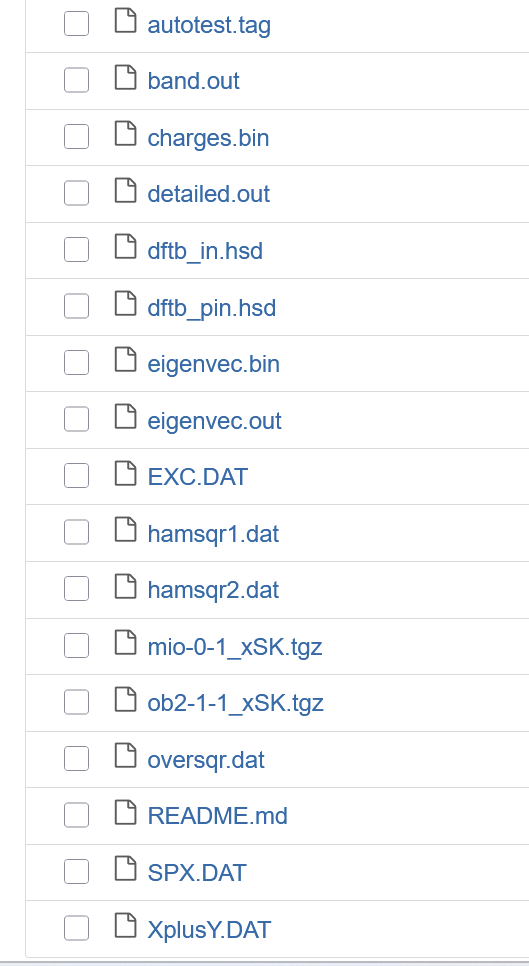

In [8]:
files = ["autotest.tag", "band.out", "charges.bin", "detailed.out", 
         "dftb_in.hsd", "dftb_pin.hsd", 
         "eigenvec.bin", "eigenvec.out",
         "EXC.DAT", "NACV.DAT", "SPX.DAT", "XplusY.DAT" ]
os.system("mkdir calc2")
for it in files:
    os.system( F"mv {it} calc2")

mkdir: cannot create directory ‘calc2’: File exists


## 5. Parsing information from the DFTB+ output
<a name="5"></a>
[Back to TOC](#toc)

### 5.1. SPX mappigs
<a name="5.1"></a>
[Back to TOC](#toc)
<a name="read_spx_mappings-1"></a>

In [9]:
help(DFTB_methods.read_spx_mappings)

Help on function read_spx_mappings in module libra_py.packages.dftbplus.methods:

read_spx_mappings(filename)
    Parse an SPX.DAT file and construct forward and reverse mappings
    between orbital transitions and RPA indices.
    
    This function reads an SPX.DAT file (as produced e.g. by TDDFT/RPA
    implementations) and builds:
    
    1. rpa_map[ini, fin, spin] -> rpa_idx
       A forward lookup table mapping a transition from orbital `ini`
       to orbital `fin` with a given spin to its corresponding RPA index.
    
    2. transition_lookup[rpa_idx] -> (ini, fin, spin)
       A reverse lookup table mapping an RPA index back to the
       corresponding transition.
    
    3. actual_max_spin
       Indicates whether spin-down transitions are present:
           - 0 : restricted / unpolarized (only spin-up or no spin label)
           - 1 : unrestricted (both U and D spins present)
    
    All indices returned by this function are **0-based**, following
    standard Python co

In [10]:
## SPX
rpa_map, rpa_lookup, max_spin = DFTB_methods.read_spx_mappings("calc2/SPX.DAT")

The existing transitions are:

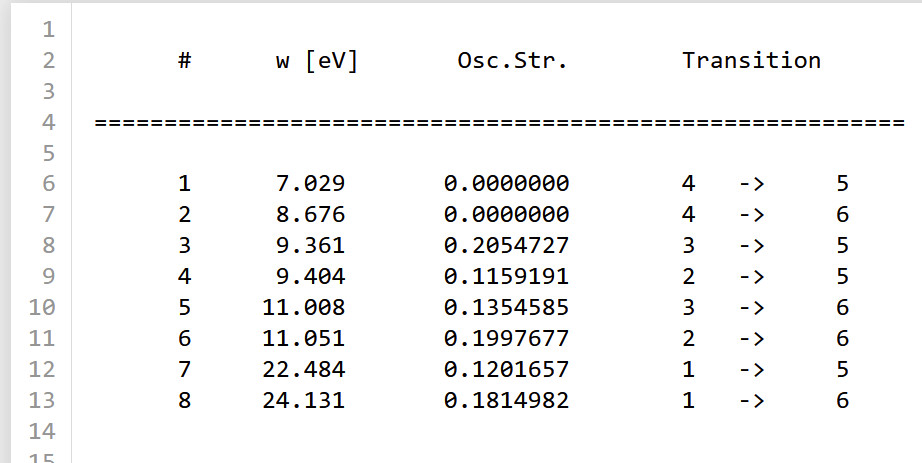

In [11]:
rpa_map.shape

(6, 6, 1)

In [12]:
print(rpa_map[:,:,0])

[[-1 -1 -1 -1  6  7]
 [-1 -1 -1 -1  3  5]
 [-1 -1 -1 -1  2  4]
 [-1 -1 -1 -1  0  1]
 [-1 -1 -1 -1 -1 -1]
 [-1 -1 -1 -1 -1 -1]]


What this means is that the transitions are numbered as:

` 0 + 1 = 1 -> 4+1 =5` is the configurations `6 + 1 = 7`

or 

` 3+1 = 4 -> 4+1 = 5` is the configuration `0+1 = 1`

Note that indexing inside of this mapping is follows Pythonic convention (starting from 0), so to obtain the orbital and configuration indices used in the output above (statring from 1), one needs to increment all internal indices by 1

The reverse lookup gives the orbitals (in the internal notation) for all the relevant configurations used in calculations:

In [13]:
print(rpa_lookup)

[[3 4 0]
 [3 5 0]
 [2 4 0]
 [1 4 0]
 [2 5 0]
 [1 5 0]
 [0 4 0]
 [0 5 0]]


This means that the configuration with internal index `0` is the transition between orbitals `3+1 = 4 -> 4+1 = 5`, and spin alpha (0) - just as it shows in the SPX.DAT file. 

In [14]:
# Case A: You know the orbitals, want the index
# "What is the index for lowest -> highest MO, Spin Up?"
ndim = rpa_map.shape[0]
print('RPA index (internal):', rpa_map[0,ndim-1, 0], " from the SPX.DAT file:", rpa_map[0,ndim-1, 0]+1)

RPA index (internal): 7  from the SPX.DAT file: 8


In [15]:
# Case B: You have an index (e.g., from an xpy vector), want the orbitals
# "What transition does RPA index 8 represent?"
idx = 7
m, n, s = rpa_lookup[idx]
print(f"Index {idx+1} corresponds to: Orbital {m+1} -> Orbital {n+1} (Spin {s})")

Index 8 corresponds to: Orbital 1 -> Orbital 6 (Spin 0)


### 5.2. X+Y amplitudes
<a name="5.2"></a>
[Back to TOC](#toc)
<a name="read_xplusy_ascii-1"></a>

In [16]:
help(DFTB_methods.read_xplusy_ascii)

Help on function read_xplusy_ascii in module libra_py.packages.dftbplus.methods:

read_xplusy_ascii(filename)
    Read XplusY.BIN written in Fortran *stream unformatted* mode and
    extract excitation vectors and energies.
    
    This routine parses the XplusY.BIN file typically produced by
    TDDFT / RPA / Casida solvers, where the file contains a header
    followed by per-root data blocks with optional energies and
    X+Y vectors.
    
    The binary layout is assumed to be **Fortran stream unformatted**
    (i.e., no record markers).
    
    Data type conventions (matching Fortran code):
        - dp   : REAL*8   (float64, 8 bytes)
        - ii   : INTEGER*4 (int32, 4 bytes)
        - sign : CHARACTER*1 (1 byte)
    
    Parameters
    ----------
    filename : str
        Path to the `XplusY.BIN` file.
    
    Returns
    -------
    nmat : int
        Length of each X+Y vector (number of matrix elements).
    
    nexc : int
        Number of excitation roots stored in the

In [17]:
## X+Y
# the main branch currently only has ASCII coefficients, but 
# there is a newer version of dftb+ that can also read the amplitudes for the binary file XplusY.BIN
nmat, nexc, results = DFTB_methods.read_xplusy_ascii("calc2/XplusY.DAT")
#nmat, nexc, results = read_xplusy_binary("XplusY.BIN")

In [18]:
print(nmat, nexc)

8 5


In [19]:
print(results)

[{'root': 1, 'sign': 'S', 'energy': 0.25832131854, 'vector': array([ 1.00000000e+00,  3.27422675e-18,  2.19092177e-16,  1.80469157e-16,
       -2.05157302e-16,  1.28377864e-16, -5.12723530e-17,  2.47537339e-17])}, {'root': 2, 'sign': 'S', 'energy': 0.31883163832, 'vector': array([ 2.65281882e-18, -1.00000000e+00,  1.80880136e-31,  3.01927068e-16,
       -2.83359742e-16, -1.09854371e-31, -2.94186819e-17, -3.09111459e-33])}, {'root': 3, 'sign': 'S', 'energy': 0.36214355762, 'vector': array([ 2.14604033e-16, -3.39530923e-16,  7.49188736e-17, -9.09989224e-01,
        3.83764306e-01, -4.32889363e-17,  3.04309152e-02, -8.58838150e-18])}, {'root': 4, 'sign': 'S', 'energy': 0.37067096567, 'vector': array([-8.80281267e-17,  2.32685105e-31,  7.95480882e-01,  2.97139657e-17,
       -1.71501670e-16, -5.89934280e-01, -3.35729108e-17, -3.52335107e-02])}, {'root': 5, 'sign': 'S', 'energy': 0.44231793904, 'vector': array([ 5.25394082e-17,  1.08856402e-16, -8.70387046e-17, -3.19531336e-01,
       -8.89

Coefficients of all configuraitions in each excited state

In [20]:
vectors  = np.array([r['vector'] for r in results if r['energy'] is not None])
print(vectors.T.shape)
print(vectors.T)

(8, 5)
[[ 1.00000000e+00  2.65281882e-18  2.14604033e-16 -8.80281267e-17
   5.25394082e-17]
 [ 3.27422675e-18 -1.00000000e+00 -3.39530923e-16  2.32685105e-31
   1.08856402e-16]
 [ 2.19092177e-16  1.80880136e-31  7.49188736e-17  7.95480882e-01
  -8.70387046e-17]
 [ 1.80469157e-16  3.01927068e-16 -9.09989224e-01  2.97139657e-17
  -3.19531336e-01]
 [-2.05157302e-16 -2.83359742e-16  3.83764306e-01 -1.71501670e-16
  -8.89951655e-01]
 [ 1.28377864e-16 -1.09854371e-31 -4.32889363e-17 -5.89934280e-01
   1.03542942e-16]
 [-5.12723530e-17 -2.94186819e-17  3.04309152e-02 -3.35729108e-17
   7.87090995e-02]
 [ 2.47537339e-17 -3.09111459e-33 -8.58838150e-18 -3.52335107e-02
  -1.99472414e-17]]


In [21]:
au2ev = 27.211386

# Access a specific Root (e.g., Root 2, which is index 1)
ridx = 1
root_data = results[ridx]
print(f"Energy for root {ridx+1}: {au2ev*root_data['energy']} eV")
# Extract the xpy vector (the RPA eigenvector)
# This is a 1D NumPy array of length 'nmat'
xpy = root_data['vector']

Energy for root 2: 8.675850779337912 eV


In [22]:
# Checking norm of vector
print(f'First entries X+Y eigenvector for root {ridx+1}: {xpy[0:5]}')
for iRoot in range(nexc):
    root_data = results[iRoot]
    xpy = root_data['vector']
    # Note that (X+Y)(X-Y) = 1, this is just a rough check of normalization
    print(f'X+Y norm for root {iRoot+1}: {sum(xpy[:]**2)}')

First entries X+Y eigenvector for root 2: [ 2.65281882e-18 -1.00000000e+00  1.80880136e-31  3.01927068e-16
 -2.83359742e-16]
X+Y norm for root 1: 1.0
X+Y norm for root 2: 1.0
X+Y norm for root 3: 0.9762814708467811
X+Y norm for root 4: 0.9820536882701192
X+Y norm for root 5: 0.9003093449351365


### 5.3. MO coefficients
<a name="5.3"></a>
[Back to TOC](#toc)
<a name="read_mo_matrix-1"></a>

In [23]:
help(DFTB_methods.read_mo_matrix)

Help on function read_mo_matrix in module libra_py.packages.dftbplus.methods:

read_mo_matrix(filename, ndim, spin_polarized=False)
    Read molecular orbital (MO) eigenvector matrices from a binary file
    written in Fortran unformatted (stream) style.
    
    The function always returns a 3D NumPy array with shape
    ``(nspin, ndim, ndim)``, where ``nspin`` is 1 for non–spin-polarized
    calculations and 2 for spin-polarized ones.
    
    Binary layout
    -------------
    The file is assumed to contain MO coefficient matrices written in
    **column-major (Fortran) order** with the following layout:
    
    * Record 1 (spin-up or total):
        - 4-byte integer header (typically a Fortran record marker or
          auxiliary integer; its value is not used)
        - ``ndim × ndim`` double-precision floating-point numbers (float64)
    
    * Record 2 (spin-down, only if ``spin_polarized=True``):
        - ``ndim × ndim`` double-precision floating-point numbers (float64)
    

In [25]:
## MO data
ndim = rpa_map.shape[1]
spin_polarized = bool(rpa_map.shape[2]-1)
mo = DFTB_methods.read_mo_matrix("calc2/eigenvec.bin", ndim, spin_polarized=spin_polarized)
# mo[spin,mu,i] corresponds to c_mu_i

In [26]:
print(mo.shape)
print(mo)

(1, 6, 6)
[[[ 9.23879537e-01 -2.85744128e-01  0.00000000e+00  1.23259516e-32
   -4.78059195e-17 -4.40755963e-01]
  [-2.04162108e-03  7.41771981e-01 -2.77555756e-17  3.08148791e-32
   -2.44514816e-18 -7.39449573e-01]
  [-8.64232643e-18  1.23579879e-17 -7.30502508e-01  2.25622503e-16
    7.35297993e-01 -1.51341535e-17]
  [ 0.00000000e+00  0.00000000e+00  3.88578059e-16  1.00000000e+00
    1.11022302e-16  0.00000000e+00]
  [ 1.21571198e-01  3.27326196e-01 -4.02857473e-01  2.15526790e-16
   -6.99447269e-01  6.32252870e-01]
  [ 1.21571198e-01  3.27326196e-01  4.02857473e-01 -2.15526790e-16
    6.99447269e-01  6.32252870e-01]]]


### 5.4. AO overlaps 
<a name="5.4"></a>
[Back to TOC](#toc)

And we will also check the orthonormality of MOs
<a name="read_overlap_matrix-1"></a>

In [27]:
help(DFTB_methods.read_overlap_matrix)

Help on function read_overlap_matrix in module libra_py.packages.dftbplus.methods:

read_overlap_matrix(filename, n_orb)
    Read an ASCII overlap matrix written in Fortran format and return it as
    a NumPy array.
    
    The file is assumed to contain a square overlap matrix stored as a
    flat list of numbers in **column-major (Fortran) order**, preceded by
    a fixed-length header.
    
    Parameters
    ----------
    filename : str
        Path to the ASCII file containing the overlap matrix.
        The numerical values are assumed to be written in a format such as
        ES24.15 (or similar), which `numpy.loadtxt` can parse automatically.
    n_orb : int
        Number of orbitals. The overlap matrix dimension is
        (n_orb, n_orb).
    
    Returns
    -------
    matrix : numpy.ndarray, shape (n_orb, n_orb)
        Overlap matrix reconstructed in the correct two-dimensional form.
    
    Notes
    -----
    * The first 5 lines of the file are treated as a header an

In [28]:
## Overlap matrix
S = DFTB_methods.read_overlap_matrix('calc1/oversqr.dat', ndim)
for iSpin in range(mo.shape[0]):
    print(f"Checking MO orthornormality for spin {iSpin}")
    mat = mo[iSpin,:,:].T @ S @ mo[iSpin,:,:]
    DFTB_methods.check_unity_deviation(mat)

Checking MO orthornormality for spin 0
--- Matrix Deviation Analysis (6x6) ---
Max Absolute Deviation: 6.66e-16


### 5.5. Forces from `autotest.tag` 
<a name="5.5"></a>
[Back to TOC](#toc)
<a name="parse_tagged_file-1"></a>

In [29]:
help(DFTB_methods.parse_tagged_file)

Help on function parse_tagged_file in module libra_py.packages.dftbplus.methods:

parse_tagged_file(file_path)
    Parse a tagged ASCII data file and return its contents as a dictionary.
    
    The file is assumed to consist of *tagged data blocks*, where each block
    starts with a header line describing the data, followed by one or more
    lines containing the numerical values.
    
    File format
    -----------
    Each data block has the form:
    
        <tag> : <dtype> : <dim> : <shape>
        <data values ...>
    
    where:
    
    * ``tag``   : string identifier used as the dictionary key
    * ``dtype`` : data type specifier (e.g. ``integer`` or ``real``)
    * ``dim``   : dimensionality of the data
                  - 0 → scalar
                  - 1 → vector
                  - 2 → matrix (or higher-rank array if supported)
    * ``shape`` : comma-separated list of dimensions
                  (ignored for ``dim = 0``)
    
    Example
    -------
    Scalar value

In [31]:
## autotest.tag
results = DFTB_methods.parse_tagged_file("calc2/autotest.tag")
forces = results['forces']

print(forces)
# If in DFTB+ PrintForces = yes, the forces under the forces tag are for the excited state StateOfInterest
# Forces are given in Hartree / Bohr
print(f'x-component of force on second atom:  {forces[0,1]}')

[[ 7.89050893e-18 -3.14472640e-17  2.35567551e-17]
 [-8.39854284e-02  4.19927142e-02  4.19927142e-02]
 [ 4.38017678e-17  5.25079901e-02 -5.25079901e-02]]
x-component of force on second atom:  -3.14472640135476e-17


### 5.6. NAC vectors from `NACV.DAT` 
<a name="5.6"></a>
[Back to TOC](#toc)
<a name="read_nacv-1"></a>

In [32]:
help(DFTB_methods.read_nacv)

Help on function read_nacv in module libra_py.packages.dftbplus.methods:

read_nacv(filename)
    Parse a NACV.DAT file and return nonadiabatic coupling vectors (NACVs)
    as a 4D NumPy array.
    
    The returned array has the shape:
    
        nacv[state_i, state_j, dim, atom_index]
    
    where:
        * state_i, state_j : electronic state indices as they appear in
          the file (typically 1-based if the file is 1-based)
        * dim              : Cartesian component (0 = X, 1 = Y, 2 = Z)
        * atom_index       : atom index (0-based)
    
    File format
    -----------
    The file is assumed to consist of repeated blocks of the form:
    
        state_i  state_j
        x_1  y_1  z_1
        x_2  y_2  z_2
        ...
        x_N  y_N  z_N
    
    where N is the number of atoms. Each block gives the NACV
    ⟨ψ_i | ∇_R | ψ_j⟩ for all atoms.
    
    Parameters
    ----------
    filename : str
        Path to the NACV.DAT file.
    
    Returns
    -------
    n

In [33]:
## NACV.DAT (not available for spin-polarized systems)
# NACV  are given in 1 / Bohr
if os.path.exists("calc2/NACV.DAT"):
    nacv = DFTB_methods.read_nacv("calc2/NACV.DAT")
    print(nacv.shape)
    print(nacv)
    print(f'S1 to S2 NACV, y-component of atom 3: {nacv[1,2,1,2]}')

(3, 3, 3, 3)
[[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

  [[ 6.04383385e-17  2.94926655e-01 -2.94926655e-01]
   [-1.96288913e-17  4.43098210e-17 -2.46809297e-17]
   [ 1.23231693e-16  2.10161469e-17 -1.44247839e-16]]

  [[ 4.51357827e-01 -2.25678913e-01 -2.25678913e-01]
   [ 4.83246883e-33 -1.17430187e-16  1.17430187e-16]
   [ 1.36343218e-16 -6.81716089e-17 -6.81716089e-17]]]


 [[[-6.04383385e-17 -2.94926655e-01  2.94926655e-01]
   [ 1.96288913e-17 -4.43098210e-17  2.46809297e-17]
   [-1.23231693e-16 -2.10161469e-17  1.44247839e-16]]

  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
   [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]

  [[-6.53546014e-16  2.59882218e-16  3.93663796e-16]
   [-1.14672901e-15 -2.85557169e+00  2.85557169e+00]
   [ 4.28372658e+00 -2.14186329e+00 -2.14186329e+00]]]


 [[[-4.51357827e-